Dataset link:https://www.kaggle.com/code/anjusukumaran4/diabetes-prediction/input

# **DataUnderstanding and EDA**

**Load Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("diabetes.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'diabetes.csv'

we upload the dataset using the Pandas library that we shortened to a variable we named "pd, which helps in reading the file " and we stored the data in the variable "df".

In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


**Basic Exploration**

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


we displayed the first five rows using df.head() to get a quick overview of the data and to identify the column names.

In [ ]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


We then displayed the last five arrays using df.tail(), which helps us check for any issues reading the end of the

In [ ]:
print(df.shape)
print(df.dtypes)

(768, 9)
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


we used df.shape to show us the number of rows and columns in the database. As shown, there are 768 rows and 9 columns.

In [ ]:
print(df.duplicated().sum())

0


We used print(df.duplicated().sum()), which shows us the number of duplicates in the dataset, and printed the result, which confirms that there are No duplicates.

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


We used df.isnull().sum(), which shows us how many values are missing in each column, thus confirming that there are no missing values in our dataset.

**Descriptive Statistics**

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#**Data Preparation**

In [ ]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:",duplicates)
df = df.drop_duplicates()

Number of duplicate rows: 0


In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Outcome'], axis=1)
Y = df['Outcome']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.30, random_state=42)

We called the train_test_split function from the sklearn.model_selection library, which splits the data into training and test sections. Then, we used X = df.drop(columns=['Outcome'], axis=1). In the variable X, we placed all columns except the Outcome column. In the variable Y, we used df['Outcome'], which contains the Outcome column.

We set the size of the test data to 30%(test_size=0.30), making the training data 70%. We used random_state=42 to ensure the data splitting was not random.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

We called the StandardScaler function from the sklearn.preprocessing library, which normalizes the data where the mean = 0 and the standard deviation = 1. We placed the StandardScaler function in a variable we named scaler. fit calculates the mean and standard deviation of the training data, and transform applies the changes to the data. columns = X_train.columns keeps the column names the same. pd.DataFrame returns the data as a table again, and we saved these changes in the variable X_train.

In [ ]:
X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.836294,-0.800051,-0.535764,-0.157146,-0.189732,-1.060153,-0.614216,-0.948610
1,0.390728,-0.490543,0.128044,0.553619,2.130203,0.646467,-0.909738,-0.434667
2,-1.143050,0.437979,-0.093226,1.393614,1.478536,1.355371,-0.306991,-0.777296
3,0.083972,0.314176,-0.093226,0.036699,0.748669,0.147609,-0.906812,-0.434667
4,-0.836294,-0.552445,-2.195284,1.135154,0.027491,1.486650,-0.839515,-0.006380


We then displayed the first five rows of X_train after standrization to see the difference after processing using X_train.head()

In [ ]:
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In the variable X_test, we used the function we defined in scaler, which calculates the mean and variance. Using transform, we applied it to the X_test data. Then, using columns=X_test.columns, which we explained previously, we retrieved the same column names and used pd.DataFrame to place them again in a new table.

In [ ]:
X_test.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.697483,-0.707199,-0.646399,0.812079,0.957202,0.265760,-0.116804,0.850192
1,-0.529539,-0.273888,0.293996,0.747464,-0.693688,0.488933,-0.941923,-1.034268
2,-0.529539,-0.397691,-0.314495,-1.320215,-0.693688,-0.154332,-0.912664,-1.034268
3,1.310994,-0.428642,0.570582,-1.320215,-0.693688,-0.968258,1.129653,0.079277
4,1.004239,0.468930,1.123756,-1.320215,-0.693688,-0.272482,-0.760514,1.449793


We then displayed the first five rows of X_test after standrization to see the difference after processing using X_test.head()

# **Build the Model (Logistic Regression)**

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, Y_train)

LogisticRegression()

We called the Logistic Regression function from the sklearn.linear_model library, then we build our model and trained it on the training data.

**Make Predictions**

In [ ]:
y_pred = model.predict(X_test)

then We made predictions on the test set to test the model.

In [ ]:
print("Predicted Classes :",y_pred[:5])

Predicted Classes : [0 0 0 0 1]


We Print the Results of the Classification

# Visualizations

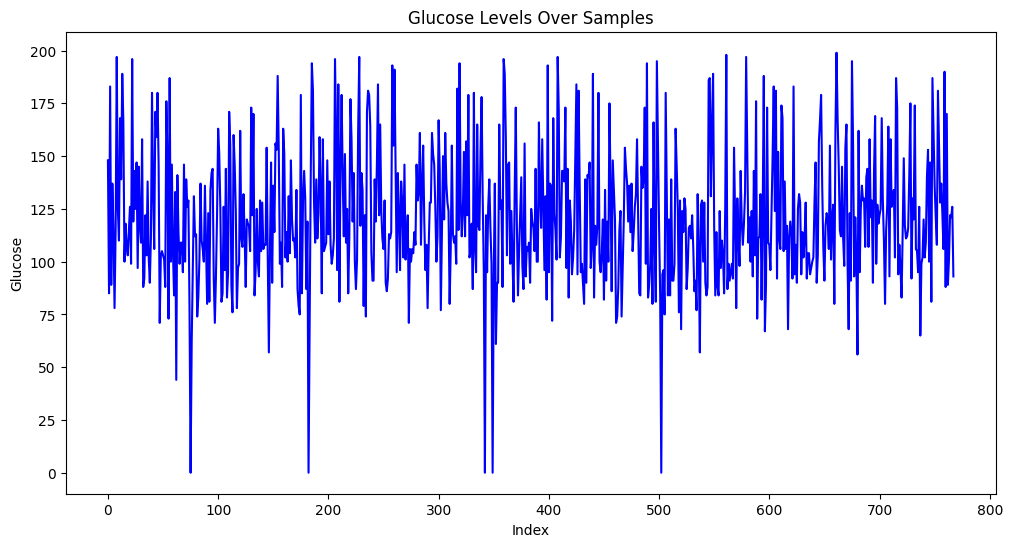

In [ ]:
# Line plot of Glucose
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Glucose'], color='blue')
plt.title('Glucose Levels Over Samples')
plt.xlabel('Index')
plt.ylabel('Glucose')
plt.show()

 Shows how glucose levels change across the dataset samples.

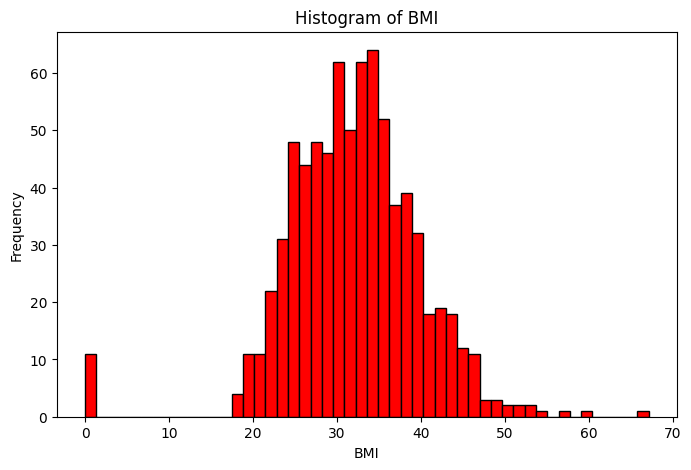

In [ ]:
# Histogram of BMI
df['BMI'] = df['BMI']
plt.figure(figsize=(8,5))
plt.hist(df['BMI'], bins=50, color='red', edgecolor='black')
plt.title('Histogram of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

Displays the distribution of BMI values in the dataset.

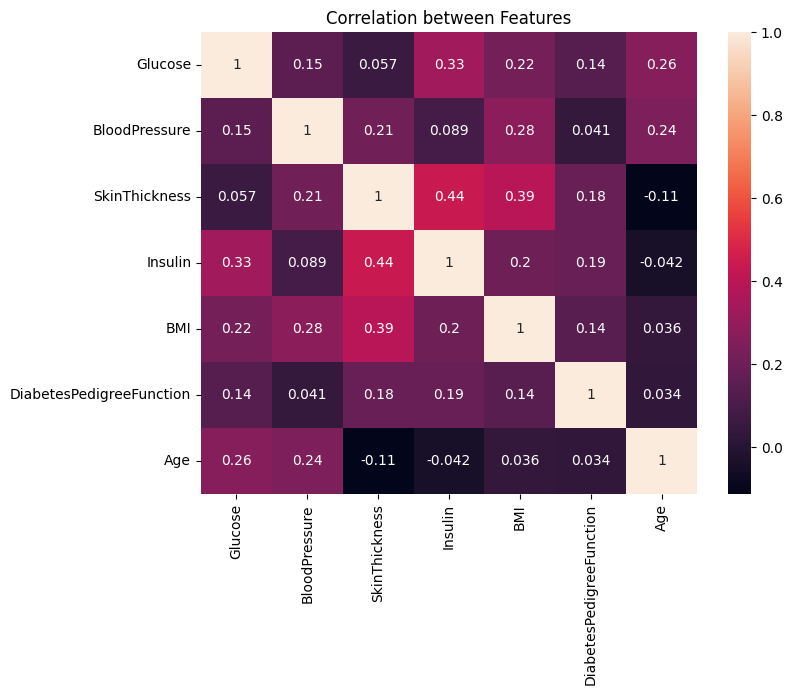

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['Glucose', 'BloodPressure', 'SkinThickness',   'Insulin', 'BMI',
'DiabetesPedigreeFunction', 'Age']].corr(), annot=True)
plt.title('Correlation between Features')
plt.show()

Shows the relationships between selected features using correlation values

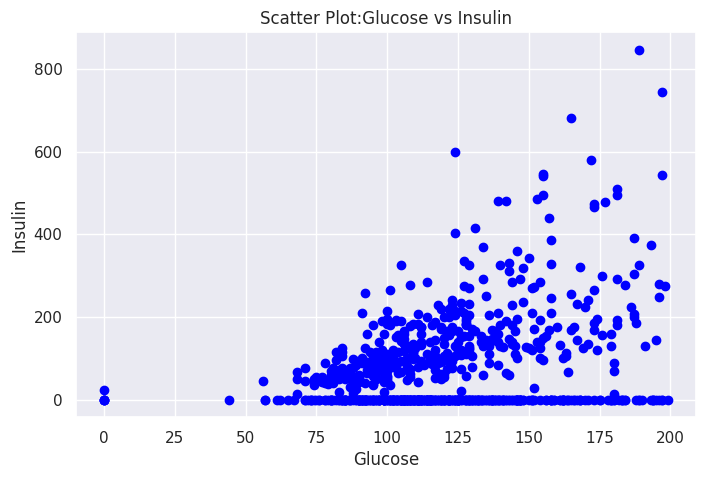

In [ ]:
# Scatter Plot: Glucose vs Insulin
plt.figure(figsize=(8,5))
plt.scatter(df['Glucose'], df['Insulin'], color='blue')
plt.title('Scatter Plot:Glucose vs Insulin')
plt.xlabel('Glucose')
plt.ylabel('Insulin')
plt.show()


Step 5: Model Evaluation

Saving diabetes.csv to diabetes (1).csv
Accuracy Score: 0.7951219512195122

Confusion Matrix:
[[115  14]
 [ 28  48]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.89      0.85       129
           1       0.77      0.63      0.70        76

    accuracy                           0.80       205
   macro avg       0.79      0.76      0.77       205
weighted avg       0.79      0.80      0.79       205



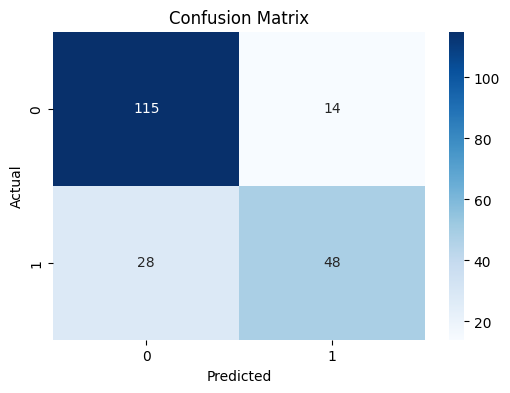

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Upload Dataset
from google.colab import files
uploaded = files.upload()

# Load Dataset
df = pd.read_csv("diabetes.csv")

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Features and Target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Logistic Regression Model
model = LogisticRegression(max_iter=1000)

# Train Model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()